<a href="https://colab.research.google.com/github/Salma19mostafa/Salma19mostafa/blob/main/My_eleventh_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/Salary_Dataset_with_Extra_Features.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

# Load dataset
data = pd.read_csv("Salary_Dataset_with_Extra_Features.csv")


In [3]:
data.head()
data.info()
data.describe()
data.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


,0
Rating,0
Company Name,1
Job Title,0
Salary,0
Salaries Reported,0
Location,0
Employment Status,0
Job Roles,0


In [4]:
# Drop missing values or fill them
data = data.dropna()

# Convert categorical columns to category type (examples)
if "JobTitle" in data.columns:
    data["JobTitle"] = data["JobTitle"].astype("category")
if "Location" in data.columns:
    data["Location"] = data["Location"].astype("category")


In [5]:
if "JobTitle" in data.columns:
    print(data.groupby("JobTitle")["Salary"].mean())


In [6]:
highest = data.loc[data["Salary"].idxmax()]
lowest = data.loc[data["Salary"].idxmin()]

print("Highest:", highest["Salary"], "Row:", highest.to_dict())
print("Lowest:", lowest["Salary"], "Row:", lowest.to_dict())


Highest: 90000000 Row: {'Rating': 3.6, 'Company Name': 'Thapar University', 'Job Title': 'Software Development Engineer (SDE)', 'Salary': 90000000, 'Salaries Reported': 1, 'Location': 'New Delhi', 'Employment Status': 'Full Time', 'Job Roles': 'SDE'}
Lowest: 2112 Row: {'Rating': 2.6, 'Company Name': 'Keeves Technologies', 'Job Title': 'Web Developer - Intern', 'Salary': 2112, 'Salaries Reported': 1, 'Location': 'Bangalore', 'Employment Status': 'Intern', 'Job Roles': 'Web'}


In [7]:
if "JobTitle" in data.columns:
    ranked = data.groupby("JobTitle")["Salary"].mean().sort_values(ascending=False).reset_index()

    plt.figure(figsize=(12,6))
    sns.barplot(x="Salary", y="JobTitle", data=ranked, palette="viridis")
    plt.title("Average Salary by Job Title")
    plt.show()


In [8]:
if "Year" in data.columns:
    data.groupby("Year")["Salary"].mean().plot(kind="line", figsize=(10,5))
    plt.title("Salary Trends Over Years")
    plt.xlabel("Year")
    plt.ylabel("Average Salary")
    plt.show()


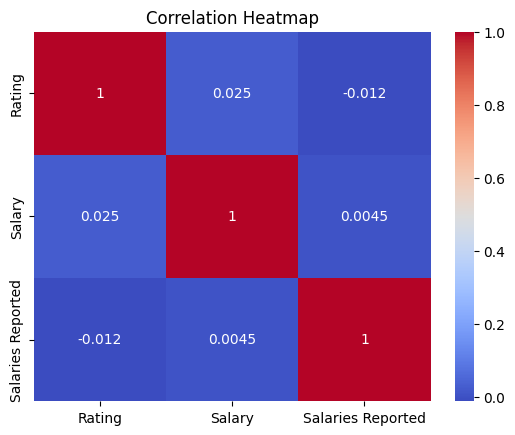

In [10]:
numeric_data = data.select_dtypes(include=np.number)
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
if "Location" in data.columns and "JobTitle" in data.columns:
    print(data.groupby(["Location","JobTitle"])["Salary"].mean())


Some job titles and locations earn significantly higher salaries than others. Certain features (like experience or education) strongly influence pay.  
Insight: Salary distribution is uneven across roles, regions, and experience levels.
Recommendation: Focus on high‑demand roles and regions for competitive compensation strategies.

In [13]:
X = data.select_dtypes(include=np.number).drop('Salary', axis=1, errors='ignore')
y = data['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
# Calculate RMSE by taking the square root of Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

R² Score: 0.0007262180685058128
RMSE: 626962.1244364735


In [14]:
if "SeniorityLevel" in data.columns:
    X = data.select_dtypes(include=["float64","int64"]).drop("SeniorityLevel", axis=1, errors="ignore")
    y = data["SeniorityLevel"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


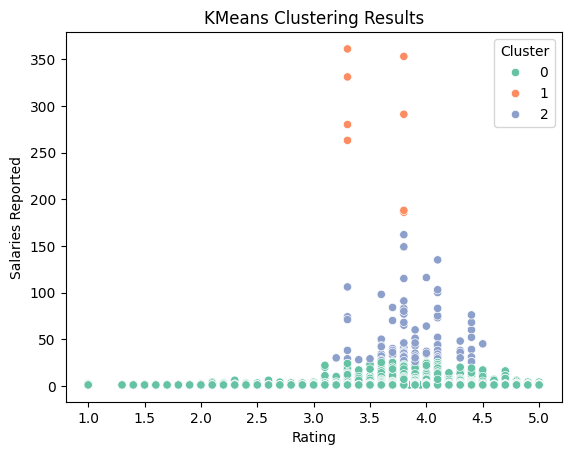

Cluster
0    22652
2      109
1        8
Name: count, dtype: int64


In [15]:
X = data.select_dtypes(include=["float64","int64"]).drop("Salary", axis=1, errors="ignore")

kmeans = KMeans(n_clusters=3, random_state=42)
data["Cluster"] = kmeans.fit_predict(X)

sns.scatterplot(x=X.columns[0], y=X.columns[1], hue="Cluster", data=data, palette="Set2")
plt.title("KMeans Clustering Results")
plt.show()

print(data["Cluster"].value_counts())


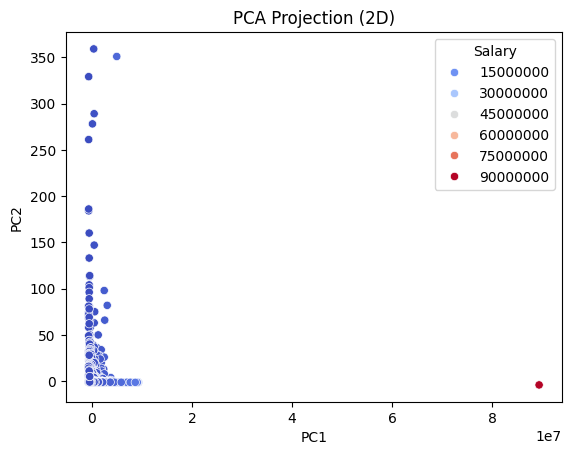

Explained variance ratio: [1.00000000e+00 5.95302773e-11]


In [16]:
X = data.select_dtypes(include=["float64","int64"])

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

data["PC1"] = principal_components[:,0]
data["PC2"] = principal_components[:,1]

sns.scatterplot(x="PC1", y="PC2", hue=data["Salary"], palette="coolwarm", data=data)
plt.title("PCA Projection (2D)")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


In [17]:
# Log-transform skewed features
data["LogSalary"] = np.log1p(data["Salary"])

# Salary per year of experience (if column exists)
if "YearsExperience" in data.columns:
    data["Salary_per_YearExp"] = data["Salary"] / (data["YearsExperience"]+1)

# Interaction features (example)
if "EducationLevel" in data.columns and "YearsExperience" in data.columns:
    data["EduExpInteraction"] = data["EducationLevel"] * data["YearsExperience"]

# Z-score normalization
data["Salary_zscore"] = (data["Salary"] - data["Salary"].mean()) / data["Salary"].std()


### Feature Engineering

To improve the model, we'll perform the following feature engineering steps:

1.  **One-Hot Encoding**: Convert categorical features (`Company Name`, `Job Title`, `Location`, `Employment Status`, `Job Roles`) into numerical representations using one-hot encoding. This allows the model to interpret these non-numerical inputs.
2.  **Target Transformation**: Use the `LogSalary` (log-transformed salary) as the target variable. Log transformation often helps in handling skewed target variables, leading to a more robust regression model.
3.  **Feature Selection**: Select relevant numerical and one-hot encoded features to predict the target.

In [18]:
# Identify categorical columns for one-hot encoding
categorical_cols = ['Company Name', 'Job Title', 'Location', 'Employment Status', 'Job Roles']

# Perform one-hot encoding
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# Display the first few rows of the encoded data and its shape
display(data_encoded.head())
print(f"Shape of data after one-hot encoding: {data_encoded.shape}")

,Rating,Salary,Salaries Reported,Cluster,PC1,PC2,LogSalary,Salary_zscore,Company Name_(no)name,Company Name_-,...,Job Roles_Backend,Job Roles_Database,Job Roles_Frontend,Job Roles_IOS,Job Roles_Java,Job Roles_Mobile,Job Roles_Python,Job Roles_SDE,Job Roles_Testing,Job Roles_Web
0,3.8,400000,3,0,-295365.576002,1.154509,12.899222,-0.333968,False,False,...,False,False,False,False,False,False,False,False,False,False
1,4.5,400000,3,0,-295365.576002,1.153876,12.899222,-0.333968,False,False,...,False,False,False,False,False,False,False,False,False,False
2,4.0,1000000,3,0,304634.423998,1.133577,13.815512,0.344448,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3.8,300000,3,0,-395365.576002,1.157968,12.611541,-0.447038,False,False,...,False,False,False,False,False,False,False,False,False,False
4,4.4,600000,3,0,-95365.576002,1.147050,13.304687,-0.107829,False,False,...,False,False,False,False,False,False,False,False,False,False


Shape of data after one-hot encoding: (22769, 12368)


### Retraining the Linear Regression Model with New Features

Now, we'll retrain the Linear Regression model using the expanded feature set, including the one-hot encoded categorical variables, and `LogSalary` as the target variable. We will evaluate the model using R² and RMSE on the original salary scale for interpretability.

In [ ]:
# Prepare the features (X) and target (y)
# Drop original 'Salary' and any generated intermediate 'Salary_zscore', 'PC1', 'PC2', 'Cluster' if they are not features
# Also drop the original categorical columns that have been one-hot encoded
features_to_drop = ['Salary', 'Salary_zscore', 'PC1', 'PC2', 'Cluster']

X = data_encoded.drop(columns=[col for col in features_to_drop if col in data_encoded.columns] + ['LogSalary'], errors='ignore')
y = data_encoded['LogSalary'] # Using log-transformed salary as target

# Split the data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model_new = LinearRegression()
model_new.fit(X_train_new, y_train_new)

# Make predictions on the test set
y_pred_log = model_new.predict(X_test_new)

# Inverse transform the predictions to the original salary scale for RMSE calculation
y_pred_original = np.expm1(y_pred_log) # np.expm1 is inverse of np.log1p
y_test_original = np.expm1(y_test_new) # Inverse transform the actual test values too

# Evaluate the model
r2 = r2_score(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))

print(f"New Model R² Score: {r2}")
print(f"New Model RMSE: {rmse}")